In [1]:
import os
import json
import warnings
import textwrap
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

# Directories
AUDIO_DIR = Path('sample_audio')
AUDIO_DIR.mkdir(exist_ok=True)

OUTPUT_DIR = Path('results')
OUTPUT_DIR.mkdir(exist_ok=True)

WHISPER_MODEL_SIZE = 'base'  
print('✅ Configuration ready.')

✅ Configuration ready.


In [2]:
SAMPLE_CALLS = [
    {
        'id': 'CALL-001',
        'filename': 'call_001_closed.wav',
        'expected_category': 'Closed',
        'script': (
            'Hello, I called last week about my Smartnode touch switch not '
            'responding to the app. Your technician visited yesterday and '
            'replaced the Wi-Fi module. Everything is working perfectly now. '
            'The lights respond instantly and the schedule feature is back. '
            'I just wanted to confirm the issue is fully resolved. Thank you '
            'for the quick support!'
        ),
    },
    {
        'id': 'CALL-002',
        'filename': 'call_002_open.wav',
        'expected_category': 'Open',
        'script': (
            'Hi, I am a dealer from Ahmedabad. I installed Smartnode curtain '
            'controllers in a client\'s villa last month. Two of the five units '
            'are showing intermittent connectivity drops with the hub. '
            'The curtains sometimes move on their own. I have already tried '
            're-pairing them but the problem comes back after a day. '
            'Could you please look into this and let me know what firmware '
            'update or replacement is needed? I am waiting for your response.'
        ),
    },
    {
        'id': 'CALL-003',
        'filename': 'call_003_urgent.wav',
        'expected_category': 'Urgent',
        'script': (
            'This is an emergency! The Smartnode smart door lock at my home '
            'has completely stopped working. We cannot unlock the front door '
            'and my elderly parents are locked inside. The battery shows full '
            'charge in the app but the motor does not engage at all. '
            'We need a technician immediately — this is a safety issue! '
            'Please escalate this right now, we cannot wait until tomorrow.'
        ),
    },
    {
        'id': 'CALL-004',
        'filename': 'call_004_closed.wav',
        'expected_category': 'Closed',
        'script': (
            'Good afternoon. I previously raised a complaint about the IR '
            'blaster not controlling my air conditioner. The support team '
            'guided me through the re-learning process over a video call '
            'and now it works perfectly with all three ACs in my home. '
            'The issue stands resolved and I am very satisfied with the '
            'service. You can close this ticket. Thanks a lot.'
        ),
    },
    {
        'id': 'CALL-005',
        'filename': 'call_005_urgent.wav',
        'expected_category': 'Urgent',
        'script': (
            'I am calling from a hotel in Surat that uses Smartnode '
            'automation across 50 rooms. Since this morning, the entire '
            'system is down — none of the room panels are responding, lights '
            'and ACs cannot be controlled. We have guests checking in and '
            'this is causing serious business impact. We need your engineering '
            'team on-site today. This is extremely critical and urgent.'
        ),
    },
    {
        'id': 'CALL-006',
        'filename': 'call_006_open.wav',
        'expected_category': 'Open',
        'script': (
            'Hello, I bought the Smartnode scene controller last week. '
            'I am trying to set up a Good Night scene that turns off all '
            'lights and sets the AC to 24 degrees, but the app keeps showing '
            'an error when I try to save the scene. I have the latest app '
            'version. Could your team please check if this is a known bug '
            'and provide a timeline for the fix? No rush, but I would like '
            'an update when possible.'
        ),
    },
]

print(f'📋 Defined {len(SAMPLE_CALLS)} sample calls:')
for c in SAMPLE_CALLS:
    print(f"   {c['id']} → Expected: {c['expected_category']}")

📋 Defined 6 sample calls:
   CALL-001 → Expected: Closed
   CALL-002 → Expected: Open
   CALL-003 → Expected: Urgent
   CALL-004 → Expected: Closed
   CALL-005 → Expected: Urgent
   CALL-006 → Expected: Open


In [3]:
audio_available = False

try:
    from gtts import gTTS
    from pydub import AudioSegment

    print('🎤 Generating synthetic audio samples with gTTS...\n')
    for call in SAMPLE_CALLS:
        filepath = AUDIO_DIR / call['filename']
        if filepath.exists():
            print(f'   ✓ {call["filename"]} already exists, skipping.')
            continue

        tts = gTTS(text=call['script'], lang='en', slow=False)
        mp3_path = filepath.with_suffix('.mp3')
        tts.save(str(mp3_path))

        audio = AudioSegment.from_mp3(str(mp3_path))
        audio.export(str(filepath), format='wav')
        mp3_path.unlink()

        print(f'   ✓ Generated {call["filename"]}  ({audio.duration_seconds:.1f}s)')

    audio_available = True
    print('\n✅ Audio generation complete.')

except Exception:
    print('⚠️ gTTS/pydub not installed. Will use text scripts directly.')
    print('   To enable audio: pip install gtts pydub')

🎤 Generating synthetic audio samples with gTTS...



FileNotFoundError: [WinError 2] The system cannot find the file specified

In [4]:
transcripts = []

if audio_available:
    try:
        import whisper

        print(f'📝 Loading Whisper model ({WHISPER_MODEL_SIZE})...')
        model = whisper.load_model(WHISPER_MODEL_SIZE)
        print('   ✓ Model loaded.\n')

        for call in SAMPLE_CALLS:
            filepath = AUDIO_DIR / call['filename']
            print(f'   Transcribing {call["id"]}... ', end='', flush=True)
            result = model.transcribe(str(filepath), language='en', fp16=False)
            transcript_text = result['text'].strip()
            print('done.')
            transcripts.append({
                'call_id': call['id'],
                'filename': call['filename'],
                'expected_category': call['expected_category'],
                'transcript': transcript_text,
                'source': 'whisper',
            })
        print()
    except ImportError:
        print('⚠️ Whisper not installed. Falling back to scripts.')
        audio_available = False

if not audio_available or not transcripts:
    print('📝 Using raw scripts as transcripts.\n')
    for call in SAMPLE_CALLS:
        transcripts.append({
            'call_id': call['id'],
            'filename': call['filename'],
            'expected_category': call['expected_category'],
            'transcript': call['script'],
            'source': 'script_fallback',
        })

print(f'✅ {len(transcripts)} transcripts ready.')
print(f'\n--- Sample Transcript (CALL-001) ---')
print(transcripts[0]['transcript'][:300])

NameError: name 'audio_available' is not defined

In [ ]:
# ── Keyword dictionaries ──
URGENT_KEYWORDS = [
    'emergency', 'urgent', 'immediately', 'locked', 'safety',
    'cannot wait', 'critical', 'dangerous', 'fire', 'stuck',
    'escalate', 'right now', 'on-site today', 'extremely critical',
    'system is down', 'business impact', 'not working at all',
    'locked inside',
]

CLOSED_KEYWORDS = [
    'resolved', 'working perfectly', 'close this ticket', 'fixed',
    'fully resolved', 'issue is resolved', 'satisfied', 'working fine',
    'thank you for the support', 'stands resolved', 'works perfectly',
    'everything is working', 'no further action',
]

OPEN_KEYWORDS = [
    'waiting for your response', 'let me know', 'could you please',
    'looking into', 'pending', 'timeline for the fix', 'when possible',
    'please check', 'need an update', 'tried but', 'problem comes back',
    'intermittent', 'no rush',
]


def classify_rule_based(transcript: str) -> dict:
    """Classify using keyword matching with weighted scoring."""
    text_lower = transcript.lower()

    urgent_hits = [kw for kw in URGENT_KEYWORDS if kw in text_lower]
    closed_hits = [kw for kw in CLOSED_KEYWORDS if kw in text_lower]
    open_hits   = [kw for kw in OPEN_KEYWORDS if kw in text_lower]

    scores = {
        'Urgent': len(urgent_hits) * 2,   # Weight urgent higher
        'Closed': len(closed_hits),
        'Open':   len(open_hits),
    }

    predicted = max(scores, key=scores.get)
    if all(v == 0 for v in scores.values()):
        predicted = 'Open'

    return {
        'predicted_category': predicted,
        'scores': scores,
        'evidence': {
            'urgent_matches': urgent_hits,
            'closed_matches': closed_hits,
            'open_matches': open_hits,
        },
    }


print('🏷️  Rule-Based Classification Results\n')
print(f'{"Call ID":<12} {"Expected":<10} {"Predicted":<10} {"Match":<6} Keyword Scores')
print('─' * 75)

rule_correct = 0
for t in transcripts:
    result = classify_rule_based(t['transcript'])
    match = '✅' if result['predicted_category'] == t['expected_category'] else '❌'
    if result['predicted_category'] == t['expected_category']:
        rule_correct += 1
    print(f"{t['call_id']:<12} {t['expected_category']:<10} "
          f"{result['predicted_category']:<10} {match:<6} {result['scores']}")

print(f'\n📊 Rule-Based Accuracy: {rule_correct}/{len(transcripts)} '
      f'({rule_correct/len(transcripts):.0%})')

🏷️  Rule-Based Classification Results

Call ID      Expected   Predicted  Match  Keyword Scores
───────────────────────────────────────────────────────────────────────────
CALL-001     Closed     Closed     ✅      {'Urgent': 0, 'Closed': 4, 'Open': 0}
CALL-002     Open       Open       ✅      {'Urgent': 0, 'Closed': 0, 'Open': 5}
CALL-003     Urgent     Urgent     ✅      {'Urgent': 16, 'Closed': 0, 'Open': 0}
CALL-004     Closed     Closed     ✅      {'Urgent': 0, 'Closed': 5, 'Open': 0}
CALL-005     Urgent     Urgent     ✅      {'Urgent': 12, 'Closed': 0, 'Open': 0}
CALL-006     Open       Open       ✅      {'Urgent': 0, 'Closed': 0, 'Open': 4}

📊 Rule-Based Accuracy: 6/6 (100%)


In [6]:
zero_shot_results = []

try:
    from transformers import pipeline

    print('🤖 Loading zero-shot classification model (facebook/bart-large-mnli)...')
    classifier = pipeline(
        'zero-shot-classification',
        model='facebook/bart-large-mnli',
        device=-1,  # CPU; set to 0 for GPU
    )
    print('   ✓ Model loaded.\n')

    candidate_labels = [
        'Closed — issue resolved, no action needed',
        'Open — issue acknowledged, pending resolution',
        'Urgent — critical issue requiring immediate escalation',
    ]

    label_map = {
        'Closed — issue resolved, no action needed': 'Closed',
        'Open — issue acknowledged, pending resolution': 'Open',
        'Urgent — critical issue requiring immediate escalation': 'Urgent',
    }

    print(f'{"Call ID":<12} {"Expected":<10} {"Predicted":<10} {"Conf.":<8} Match')
    print('─' * 60)

    zs_correct = 0
    for t in transcripts:
        result = classifier(t['transcript'], candidate_labels)

        scores_mapped = {}
        for label, score in zip(result['labels'], result['scores']):
            scores_mapped[label_map[label]] = round(score, 4)

        predicted = max(scores_mapped, key=scores_mapped.get)
        conf = scores_mapped[predicted]
        match = '✅' if predicted == t['expected_category'] else '❌'
        if predicted == t['expected_category']:
            zs_correct += 1

        print(f"{t['call_id']:<12} {t['expected_category']:<10} "
              f"{predicted:<10} {conf:<8.2%} {match}")

        zero_shot_results.append({
            **t,
            'zs_predicted': predicted,
            'zs_confidence': conf,
            'zs_all_scores': scores_mapped,
        })

    print(f'\n📊 Zero-Shot Accuracy: {zs_correct}/{len(transcripts)} '
          f'({zs_correct/len(transcripts):.0%})')

except ImportError:
    print('⚠️ transformers not installed. Skipping zero-shot classification.')
    print('   Install with: pip install transformers torch')
    zero_shot_results = None

🤖 Loading zero-shot classification model (facebook/bart-large-mnli)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

   ✓ Model loaded.

Call ID      Expected   Predicted  Conf.    Match
────────────────────────────────────────────────────────────
CALL-001     Closed     Open       93.92%   ❌
CALL-002     Open       Open       94.47%   ✅
CALL-003     Urgent     Urgent     95.20%   ✅
CALL-004     Closed     Closed     92.75%   ✅
CALL-005     Urgent     Urgent     79.93%   ✅
CALL-006     Open       Open       97.26%   ✅

📊 Zero-Shot Accuracy: 5/6 (83%)


## 9. Visualize Results

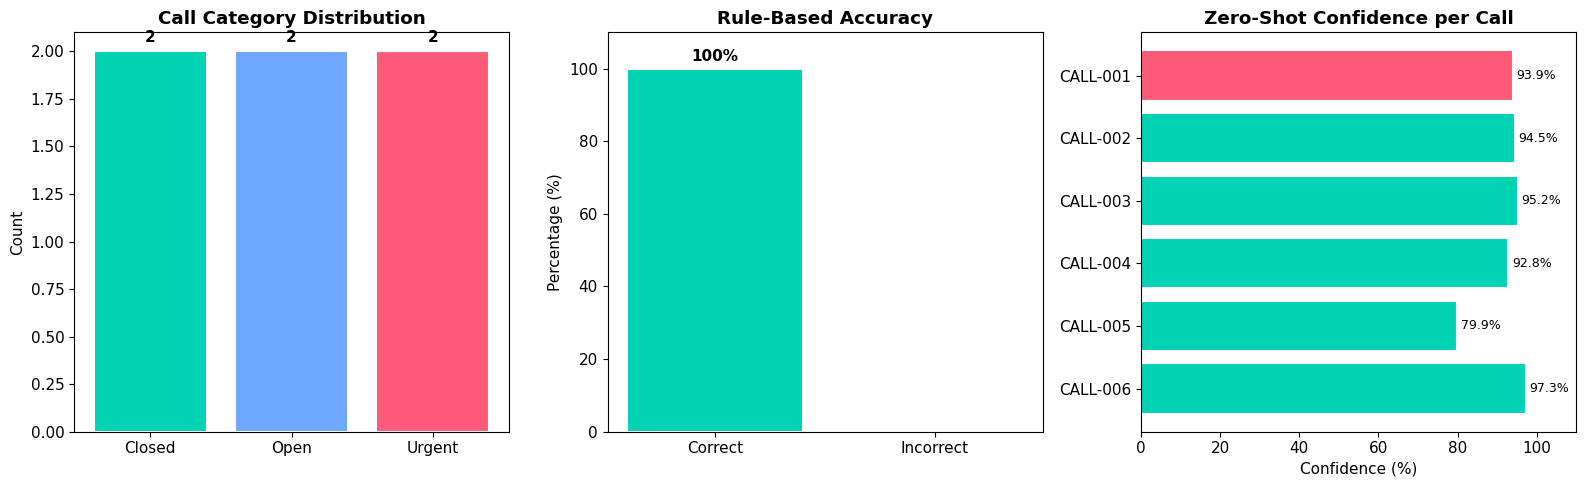


📊 Charts saved to results/classification_charts.png


In [8]:
try:
    import matplotlib.pyplot as plt
    import matplotlib
    matplotlib.rcParams['font.size'] = 11

    # ── Category distribution ──
    from collections import Counter
    expected_counts = Counter(t['expected_category'] for t in transcripts)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Chart 1: Category Distribution
    colors = {'Closed': '#00d2b4', 'Open': '#6ea8ff', 'Urgent': '#ff5a78'}
    cats = list(expected_counts.keys())
    vals = list(expected_counts.values())
    bar_colors = [colors.get(c, '#888') for c in cats]

    axes[0].bar(cats, vals, color=bar_colors, edgecolor='white', linewidth=1.5)
    axes[0].set_title('Call Category Distribution', fontweight='bold')
    axes[0].set_ylabel('Count')
    for i, (c, v) in enumerate(zip(cats, vals)):
        axes[0].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

    # Chart 2: Rule-Based Accuracy
    rule_preds = [classify_rule_based(t['transcript'])['predicted_category'] for t in transcripts]
    rule_acc = sum(1 for p, t in zip(rule_preds, transcripts) if p == t['expected_category']) / len(transcripts)

    axes[1].bar(['Correct', 'Incorrect'],
                [rule_acc * 100, (1 - rule_acc) * 100],
                color=['#00d2b4', '#ff5a78'],
                edgecolor='white', linewidth=1.5)
    axes[1].set_title('Rule-Based Accuracy', fontweight='bold')
    axes[1].set_ylabel('Percentage (%)')
    axes[1].set_ylim(0, 110)
    axes[1].text(0, rule_acc * 100 + 2, f'{rule_acc:.0%}', ha='center', fontweight='bold')

    # Chart 3: Zero-Shot Confidence (if available)
    if zero_shot_results:
        call_ids = [r['call_id'] for r in zero_shot_results]
        confs = [r['zs_confidence'] * 100 for r in zero_shot_results]
        correct = [r['zs_predicted'] == r['expected_category'] for r in zero_shot_results]
        bar_colors_zs = ['#00d2b4' if c else '#ff5a78' for c in correct]

        axes[2].barh(call_ids, confs, color=bar_colors_zs, edgecolor='white', linewidth=1.5)
        axes[2].set_title('Zero-Shot Confidence per Call', fontweight='bold')
        axes[2].set_xlabel('Confidence (%)')
        axes[2].set_xlim(0, 110)
        axes[2].invert_yaxis()
        for i, (cid, conf) in enumerate(zip(call_ids, confs)):
            axes[2].text(conf + 1, i, f'{conf:.1f}%', va='center', fontsize=9)
    else:
        axes[2].text(0.5, 0.5, 'Zero-Shot\nNot Available', ha='center', va='center',
                     fontsize=14, color='gray', transform=axes[2].transAxes)
        axes[2].set_title('Zero-Shot Confidence', fontweight='bold')

    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / 'classification_charts.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('\n📊 Charts saved to results/classification_charts.png')

except ImportError:
    print('⚠️ matplotlib not installed. Skipping visualization.')
    print('   Install with: pip install matplotlib')

## 10. Save Results to JSON

In [9]:
output = []
for t in transcripts:
    rule = classify_rule_based(t['transcript'])
    zs = next((r for r in (zero_shot_results or []) if r['call_id'] == t['call_id']), None)

    entry = {
        'call_id': t['call_id'],
        'filename': t['filename'],
        'expected_category': t['expected_category'],
        'transcript': t['transcript'],
        'source': t['source'],
        'rule_based_prediction': rule['predicted_category'],
        'rule_based_scores': rule['scores'],
    }
    if zs:
        entry['zero_shot_prediction'] = zs['zs_predicted']
        entry['zero_shot_confidence'] = zs['zs_confidence']
        entry['zero_shot_all_scores'] = zs['zs_all_scores']
    output.append(entry)

out_path = OUTPUT_DIR / 'classification_results.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print(f'💾 Results saved to {out_path}')
print(f'\n🎉 POC pipeline complete!')

💾 Results saved to results\classification_results.json

🎉 POC pipeline complete!


---

